- Name: Farrel Augusta Dinata
- Class: TI-3H
- NIM: 2341720081
- Roll number: 12

# Preparation

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Practicum

## **PRACTICUM-1: Basic Object Detection**

### 1. Implement **Template Matching**

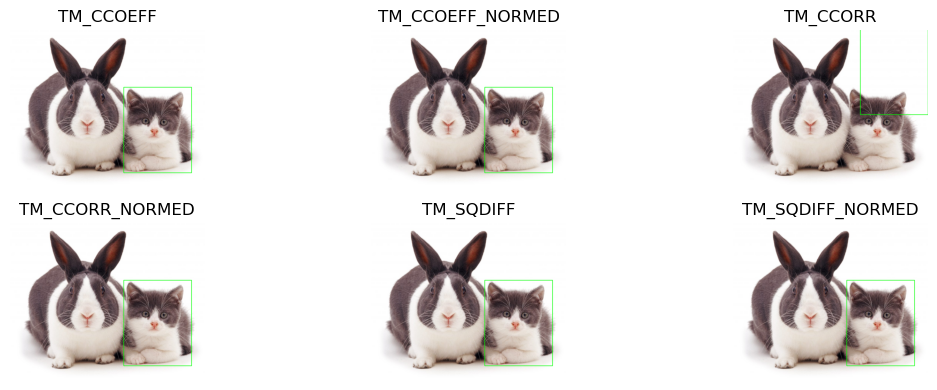

In [ ]:
img = cv2.imread('../assets/kitten_and_bunny.jpg')
template = cv2.imread('../assets/kitten_2.jpg')

if img is None or template is None:
    raise Exception('Image is nout found!')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)


match_template_methods = [
    ("TM_CCOEFF", cv2.TM_CCOEFF),
    ("TM_CCOEFF_NORMED", cv2.TM_CCOEFF_NORMED),
    ("TM_CCORR", cv2.TM_CCORR),
    ("TM_CCORR_NORMED", cv2.TM_CCORR_NORMED),
    ("TM_SQDIFF", cv2.TM_SQDIFF),
    ("TM_SQDIFF_NORMED", cv2.TM_SQDIFF_NORMED),
]



# Result visualization
# Create subplots: 2 row, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 4))
axes = axes.ravel()

# Loop through each subplot
for ax, (method_name, method) in zip(axes, match_template_methods):
    result = cv2.matchTemplate(img_gray, template_gray, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    h, w = template_gray.shape
    bottom_right = (top_left[0] + w, top_left[1] + h)

    img_display = img.copy()
    cv2.rectangle(img_display, top_left, bottom_right, (0, 255, 0), 2)

    ax.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    ax.set_title(method_name)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 2. Implement **Template Matching** from Scratch for Multiple Objects

### 3. Implement **Sobel Edge Detection, Canny Edge Detection, and Laplacian Edge Detection** with OpenCV

#### 3.1 Sobel Edge Detection

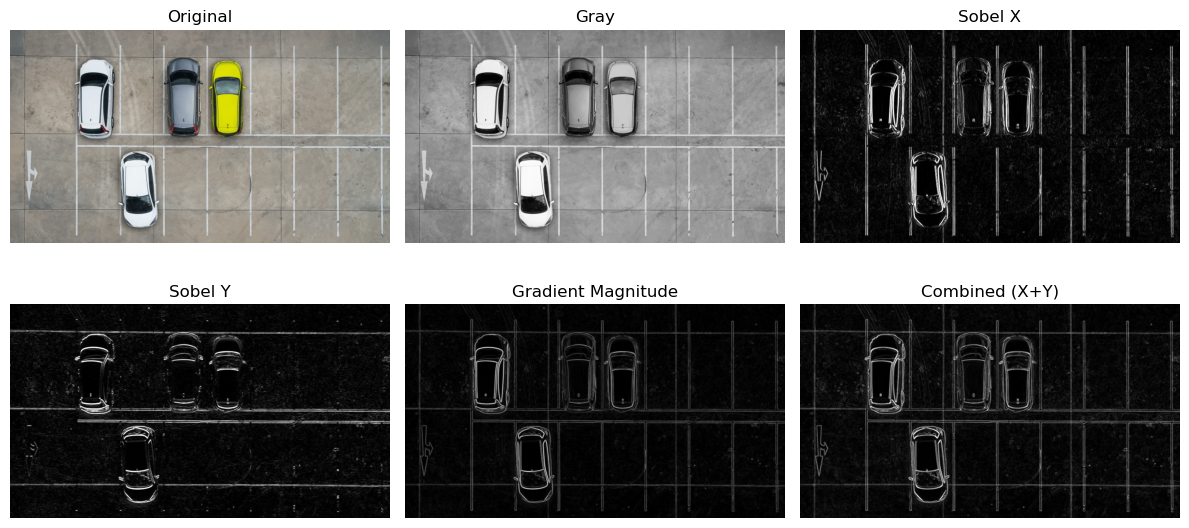

In [6]:
img = cv2.imread('../assets/car-park.png')

if img is None:
    raise Exception('Image is not found!')

# Convert to grayscale and smooth to reduce noise
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)

# Compute Sobel derivatives (float64)
sobelx_f = cv2.Sobel(gray_blur, cv2.CV_64F, 1, 0, ksize=3)
sobely_f = cv2.Sobel(gray_blur, cv2.CV_64F, 0, 1, ksize=3)

# Convert to 8-bit images for visualization (absolute)
sobelx = cv2.convertScaleAbs(sobelx_f)
sobely = cv2.convertScaleAbs(sobely_f)

# Gradient magnitude (normalized to 0-255)
magnitude = np.sqrt(sobelx_f**2 + sobely_f**2)
magnitude = (255 * (magnitude / (magnitude.max() + 1e-8))).astype(np.uint8)

# Simple combined visualization
combined = cv2.addWeighted(sobelx, 0.5, sobely, 0.5, 0)

# Prepare data for plotting
plots = [
    ('Original', cv2.cvtColor(img, cv2.COLOR_BGR2RGB)),
    ('Gray', gray),
    ('Sobel X', sobelx),
    ('Sobel Y', sobely),
    ('Gradient Magnitude', magnitude),
    ('Combined (X+Y)', combined),
]

# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

# Loop through subplots and images
for ax, (title, img_data) in zip(axes, plots):
    if len(img_data.shape) == 2:  # Grayscale image
        ax.imshow(img_data, cmap='gray')
    else:  # Color image
        ax.imshow(img_data)

    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 3.2 Canny Edge Detection

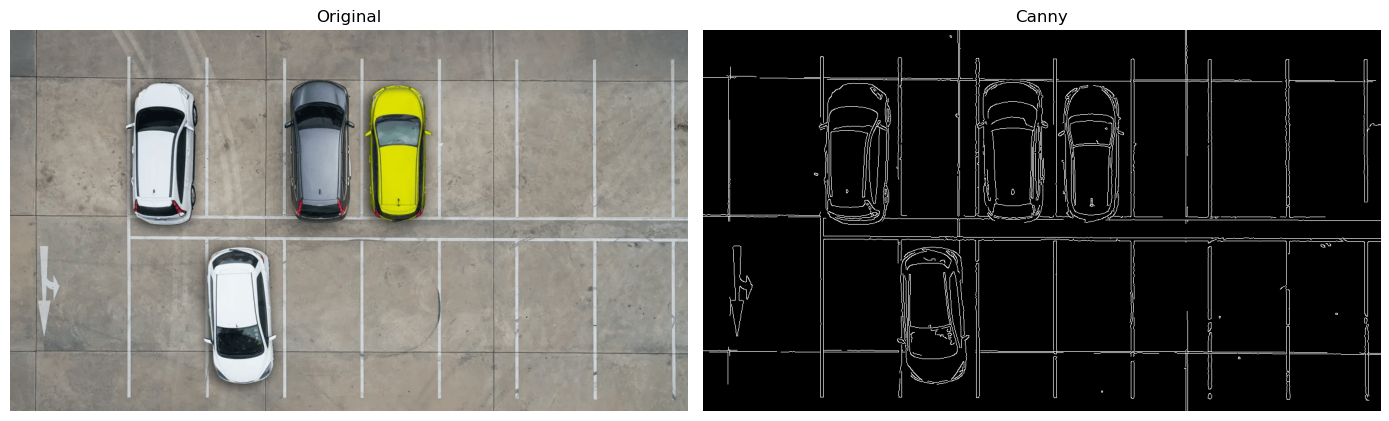

In [8]:
canny = cv2.Canny(gray_blur, threshold1=100, threshold2=200)

# Add new experiments to plots
plots = [
    ('Original', cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), # type: ignore
    ('Canny', canny),
]

# Adjust figure layout (e.g. 1 rows, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.ravel()

for ax, (title, img_data) in zip(axes, plots):
    if len(img_data.shape) == 2:
        ax.imshow(img_data, cmap='gray')
    else:
        ax.imshow(img_data)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

#### 3.3 Laplacian Edge Detection

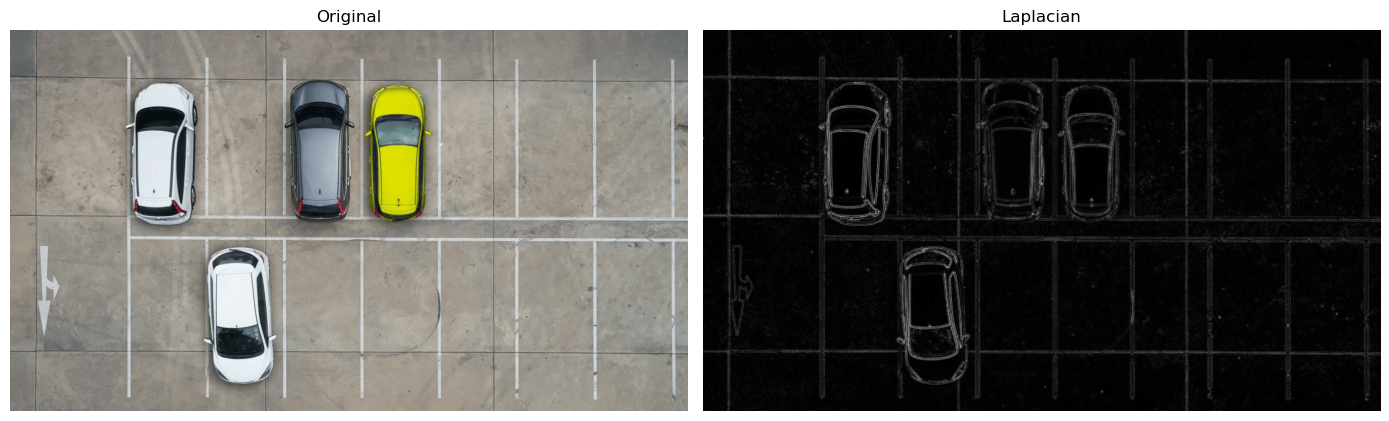

In [9]:
# Laplacian edge detection (float64)
laplacian_f = cv2.Laplacian(gray_blur, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian_f)

# Add new experiments to plots
plots = [
    ('Original', cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), # type: ignore
    ('Laplacian', laplacian),
]

# Adjust figure layout (e.g. 1 rows, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.ravel()

for ax, (title, img_data) in zip(axes, plots):
    if len(img_data.shape) == 2:
        ax.imshow(img_data, cmap='gray')
    else:
        ax.imshow(img_data)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 4. Implement **Harris Corner and Shi-Tomasi Detection** with OpenCV

#### 4.1 Harris Corner Detection

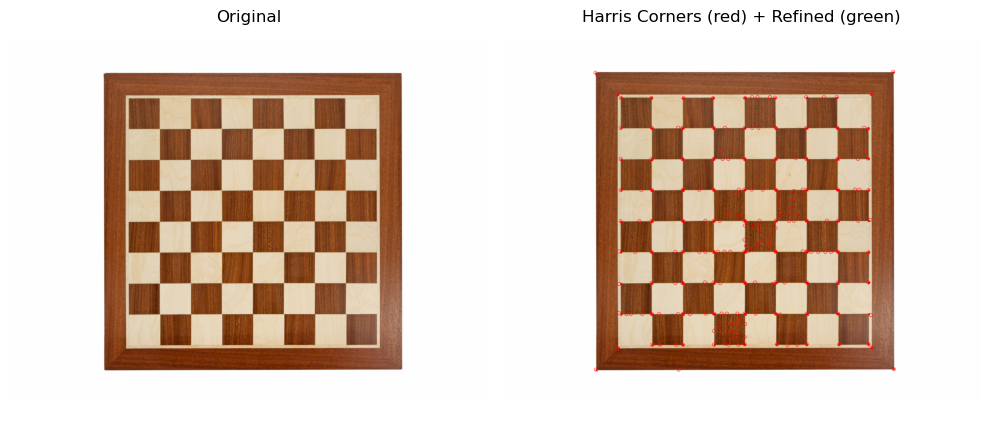

In [11]:
img = cv2.imread('../assets/chess-board.jpg')

if img is None:
    raise Exception('Image is not found!')

# Convert to grayscale and to float32 for Harris
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_f = np.float32(gray)

# Harris corner detector
dst = cv2.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04) # type: ignore

# Dilate result to mark the corners
dst_dilated = cv2.dilate(dst, None) # type: ignore

# Create copy for visualization and mark detected corners in red (BGR)
img_harris = img.copy()
threshold = 0.01 * dst_dilated.max()
img_harris[dst_dilated > threshold] = [0, 0, 255]

# Optional: refine corners to sub-pixel accuracy using goodFeaturesToTrack + cornerSubPix
corners = cv2.goodFeaturesToTrack(gray, maxCorners=200, qualityLevel=0.01, minDistance=8)
if corners is not None:
    corners = np.float32(corners)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001)
    cv2.cornerSubPix(gray, corners, winSize=(5,5), zeroZone=(-1,-1), criteria=criteria) # type: ignore
    for c in corners: # type: ignore
        x, y = c.ravel()
        cv2.circle(img_harris, (int(x), int(y)), 4, (0, 0, 255), 1)  # refined corners in red

# Plot original and Harris result
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_harris, cv2.COLOR_BGR2RGB))
axes[1].set_title('Harris Corners (red) + Refined (green)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### 4.2 Shi-Tomasi Detection

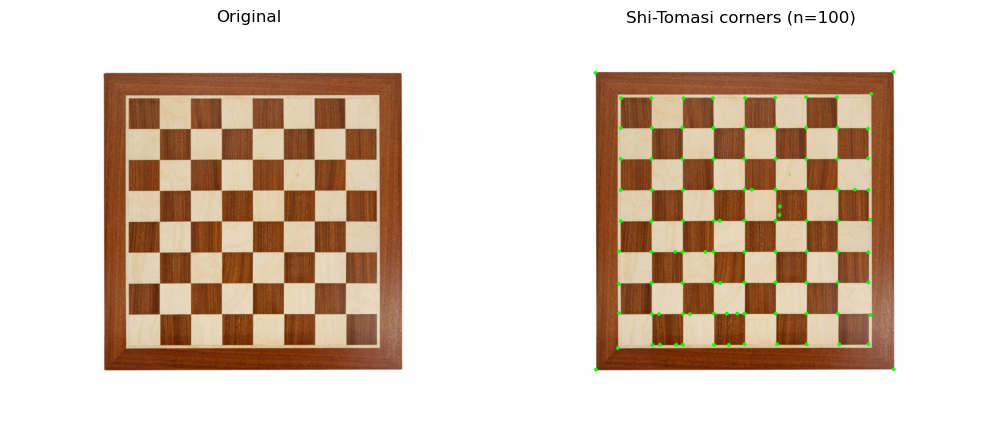

In [12]:
img = cv2.imread('../assets/chess-board.jpg')

if img is None:
    raise Exception('Image is not found!')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Shi-Tomasi (Good Features to Track) parameters
max_corners = 100
quality_level = 0.01
min_distance = 10
block_size = 3
use_harris = False

corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=max_corners,
    qualityLevel=quality_level,
    minDistance=min_distance,
    blockSize=block_size,
    useHarrisDetector=use_harris
)

# Optional: refine to sub-pixel accuracy
if corners is not None:
    corners = np.float32(corners)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001)
    cv2.cornerSubPix(gray, corners, winSize=(5,5), zeroZone=(-1,-1), criteria=criteria) # type: ignore

# Draw detected corners
img_st = img.copy()
if corners is not None:
    for c in corners: # type: ignore
        x, y = c.ravel()
        cv2.circle(img_st, (int(x), int(y)), 4, (0, 255, 0), -1)

# Display original and result
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_st, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Shi-Tomasi corners (n={0 if corners is None else len(corners)})') # type: ignore
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 5. Implement **Hough Transform** with OpenCV

### 6. Implement Function **findContours()** for Countour Detection

## **PRACTICUM-2: Feature Matching and Face Detection**

### 1. Face Detection Practice

### 2. Perform Object Detection with Bounding Box to Cat Head

### 3. Perform Object Detection with Bounding Box to Eye Object

### 4. Perform Smile Detection On The Image Of People

### 5. Perform Face Tracking

### 6. Apply Blurring To The Detected Face Area